# EDA — ChemAI: Predict the Cure

Исследовательский анализ данных: распределения таргетов, инсайты, признаки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TARGET_IC50 = 'IC50, mM'
TARGET_CC50 = 'CC50, mM'
TARGET_SI   = 'SI'
TARGETS     = [TARGET_IC50, TARGET_CC50, TARGET_SI]

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (751, 214)
Test:  (250, 211)


## 1. Распределения таргетов

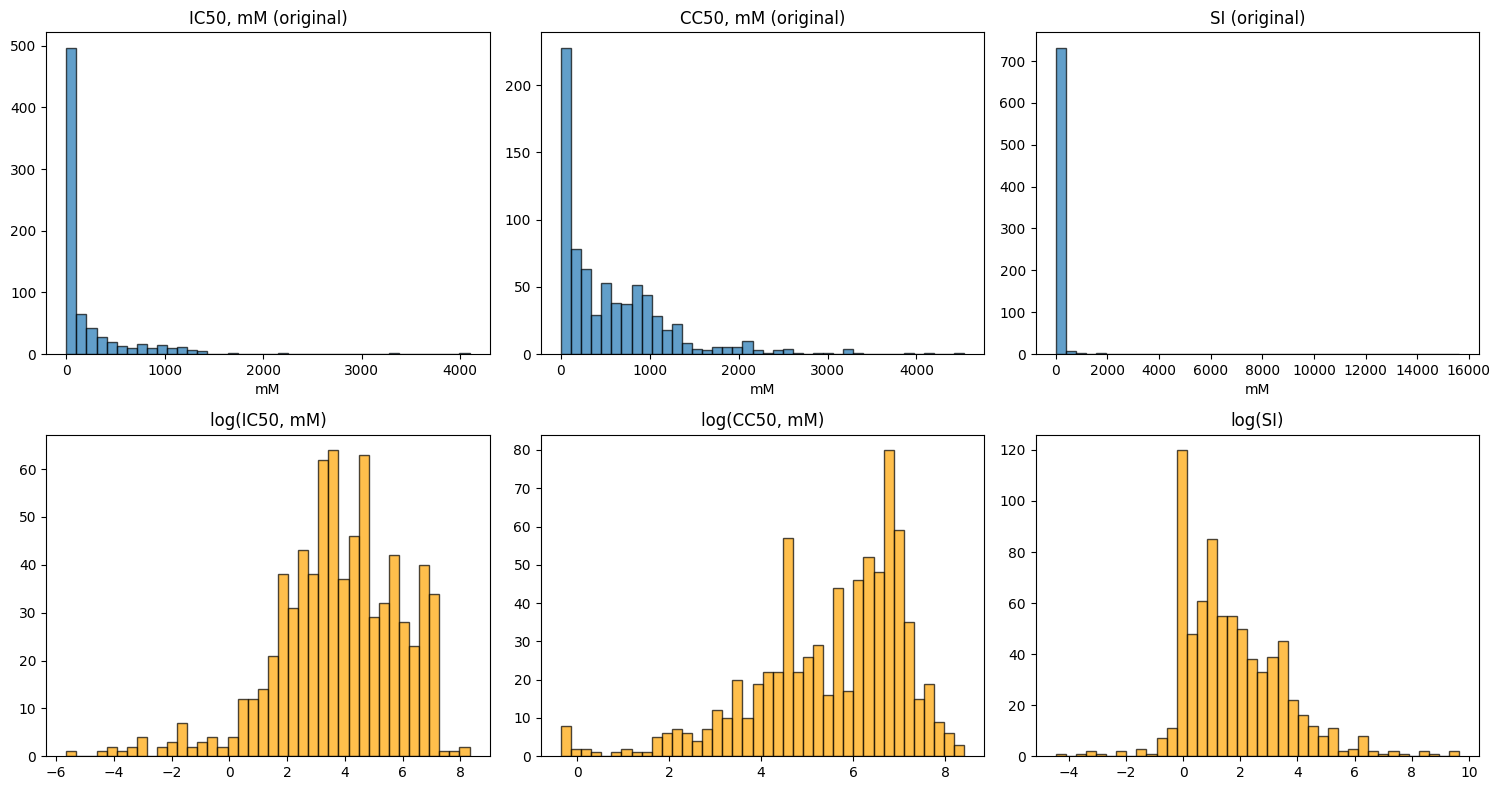

Статистика таргетов:
       IC50, mM  CC50, mM        SI
count    751.00    751.00    751.00
mean     204.54    577.43     89.15
std      370.37    641.52    788.88
min        0.00      0.70      0.01
25%       13.22    100.00      1.50
50%       44.07    376.58      4.00
75%      206.79    877.51     17.37
max     4095.19   4538.98  15620.60


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(TARGETS):
    axes[0, i].hist(train[col], bins=40, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f'{col} (original)')
    axes[0, i].set_xlabel('mM')

    axes[1, i].hist(np.log(train[col]), bins=40, edgecolor='k', alpha=0.7, color='orange')
    axes[1, i].set_title(f'log({col})')

plt.tight_layout()
plt.show()

print('Статистика таргетов:')
print(train[TARGETS].describe().round(2))

## 2. Инвариант SI = CC50 / IC50

In [3]:
si_calc = train[TARGET_CC50] / train[TARGET_IC50]
err     = (train[TARGET_SI] - si_calc).abs()
print(f'SI = CC50/IC50: максимальная ошибка = {err.max():.2e}')
print(f'Совпадение (err < 1e-6): {(err < 1e-6).mean():.1%}')
print('Вывод: log(SI) = log(CC50) - log(IC50) — используем как дополнительный признак и для бленда')

SI = CC50/IC50: максимальная ошибка = 2.00e-11
Совпадение (err < 1e-6): 100.0%
Вывод: log(SI) = log(CC50) - log(IC50) — используем как дополнительный признак и для бленда


## 3. Пропуски и константные признаки

In [4]:
feat_cols = [c for c in train.columns if c not in ['index'] + TARGETS]

missing = train[feat_cols].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Признаков с пропусками: {len(missing)}')
print(missing)

const = [c for c in feat_cols if train[c].nunique() <= 1]
print(f'\nКонстантных признаков: {len(const)}')

Признаков с пропусками: 12
MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

Константных признаков: 18


## 4. Корреляция с таргетами (топ признаков)

In [5]:
feat_valid = [c for c in feat_cols if c not in const]
X = train[feat_valid].fillna(train[feat_valid].median())

for name, target in [('IC50', TARGET_IC50), ('CC50', TARGET_CC50)]:
    corr = X.corrwith(np.log(train[target])).abs().sort_values(ascending=False)
    print(f'Топ-10 по |corr| с log({name}):')
    print(corr.head(10).to_string())
    print()

Топ-10 по |corr| с log(IC50):
fr_NH2                      0.279893
NumSaturatedHeterocycles    0.267715
NumAliphaticHeterocycles    0.240949
VSA_EState4                 0.222461
fr_NH1                      0.201623
SlogP_VSA5                  0.194818
SMR_VSA5                    0.193596
Kappa3                      0.192386
NumRotatableBonds           0.185866
VSA_EState8                 0.175838



Топ-10 по |corr| с log(CC50):
Kappa3             0.264536
fr_NH2             0.227896
Kappa2             0.210072
fr_allylic_oxid    0.198822
fr_C_O_noCOO       0.194875
Kappa1             0.191540
fr_C_O             0.190609
fr_NH1             0.187289
NHOHCount          0.185396
PEOE_VSA7          0.183866



## 5. Мультиколлинеарность

In [6]:
corr_m = X.corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))

for threshold in [0.99, 0.98, 0.95, 0.90]:
    n_drop = sum(any(upper[c] > threshold) for c in upper.columns)
    print(f'r > {threshold}: {n_drop} признаков к удалению')

print('\nВывод: порог r>0.95 даёт хороший баланс между удалением шума и сохранением сигнала')

r > 0.99: 13 признаков к удалению
r > 0.98: 20 признаков к удалению
r > 0.95: 33 признаков к удалению


r > 0.9: 47 признаков к удалению

Вывод: порог r>0.95 даёт хороший баланс между удалением шума и сохранением сигнала
